# Cassini CDA Dust Analyzer: Frequency Domain Exploration

This notebook explores the visual and signal processing characteristics of Cassini Cosmic Dust Analyzer (CDA) Time-of-Flight mass spectra across different classes.

To help the Vision-Language Model (VLM) overcome its limitations in measuring precise pixel-level peak spacings, we investigate three key signal processing transformations:
1. **Fast Fourier Transform (FFT)**: Converts the time-of-flight index domain into the frequency domain. For Class 1 (constant spacing), this should yield a clean, sharp harmonic peak.
2. **Autocorrelation Function (ACF)**: Measures the self-similarity of the spectrum at different lags. Class 1 should show highly periodic peak repetition, whereas Class 2 (converging) and Class 4 (diverging) will show rapidly decaying ACF curves.
3. **Short-Time Fourier Transform (Spectrogram)**: Computes local frequency content over moving windows. Class 1 will show a horizontal frequency line, Class 2 an upward-sloping line (frequency increases), and Class 4 a downward-sloping line (frequency decreases).

All transformations are normalized to the `[0, 1]` range to ensure consistent visualization.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from dotenv import load_dotenv

# Ensure we can import from the workspace root
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from scripts.run_ablation_study_incremental import preprocess_huggingface_data

load_dotenv(dotenv_path="../.env")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load data
print("Loading HuggingFace training data...")
full_df = preprocess_huggingface_data("H")
print(f"Loaded {len(full_df)} rows of data.")
print("Class distribution:\n", full_df['class'].value_counts())

Loading HuggingFace training data...
Loaded 6986 rows of data.
Class distribution:
 class
Noise    4442
1        1183
2         829
3         246
4         210
5          42
5-Na       34
Name: count, dtype: int64


## Transformation Functions

Here, we define the mathematical transformation functions. Each function accepts the 1D spectrum array, truncates/pads it to length 630 (to match the VLM's field of view), computes the transformation, and scales the output values to the range `[0, 1]`.

In [3]:
def clean_and_truncate(spectrum, target_len=630):
    """Ensures the spectrum is a numpy array of target_len."""
    arr = np.array(spectrum)
    if len(arr) > target_len:
        return arr[:target_len]
    elif len(arr) < target_len:
        return np.pad(arr, (0, target_len - len(arr)), mode='constant')
    return arr

def compute_fft(spectrum_data):
    """Computes the FFT amplitude spectrum and normalizes it to [0, 1]."""
    signal = clean_and_truncate(spectrum_data)
    # Remove DC offset to prevent frequency 0 from dominating the plot scale
    signal_centered = signal - np.mean(signal)
    fft_vals = np.abs(np.fft.rfft(signal_centered))
    
    # Normalize to [0, 1]
    min_val = np.min(fft_vals)
    max_val = np.max(fft_vals)
    fft_vals_norm = (fft_vals - min_val) / (max_val - min_val + 1e-9)
    
    freqs = np.fft.rfftfreq(len(signal))
    return freqs, fft_vals_norm

def compute_autocorrelation(spectrum_data):
    """Computes the centered autocorrelation function and normalizes it to [0, 1]."""
    signal = clean_and_truncate(spectrum_data)
    # Center signal to highlight true periodicities rather than baseline height
    signal_centered = signal - np.mean(signal)
    
    acf = np.correlate(signal_centered, signal_centered, mode='full')
    acf = acf[acf.size // 2:]  # Keep positive lags
    
    # Normalize to [0, 1]
    min_val = np.min(acf)
    max_val = np.max(acf)
    acf_norm = (acf - min_val) / (max_val - min_val + 1e-9)
    
    lags = np.arange(len(acf_norm))
    return lags, acf_norm

def compute_spectrogram(spectrum_data, nperseg=64, noverlap=56):
    """Computes the spectrogram (STFT) and normalizes it to [0, 1]."""
    signal = clean_and_truncate(spectrum_data)
    
    # Compute spectrogram using scipy
    f, t, Sxx = spectrogram(signal, fs=1.0, nperseg=nperseg, noverlap=noverlap)
    
    # Normalize to [0, 1]
    min_val = np.min(Sxx)
    max_val = np.max(Sxx)
    Sxx_norm = (Sxx - min_val) / (max_val - min_val + 1e-9)
    
    return t, f, Sxx_norm

## Visualization Helper

This helper function creates a beautifully formatted 2x2 grid containing the Time-of-Flight spectrum, FFT, Autocorrelation, and Spectrogram for a given sample.

In [4]:
def plot_class_diagnostics(row, title_prefix=""):
    spectrum = row['spectrum']
    class_label = row['class']
    sclk = row['sclk']
    
    # Compute transformations
    freqs, fft_vals = compute_fft(spectrum)
    lags, acf_vals = compute_autocorrelation(spectrum)
    t, f, spec_vals = compute_spectrogram(spectrum)
    
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{title_prefix}Class: {class_label} | SCLK: {sclk}", fontsize=16, fontweight='bold', color='#1e293b')
    
    # 1. Top-Left: Original Spectrum (Log y-axis)
    axs[0, 0].plot(spectrum, color='#0f172a', linewidth=1.5)
    axs[0, 0].set_title("1. Time-of-Flight Spectrum (Original)", fontsize=12, fontweight='semibold', color='#334155')
    axs[0, 0].set_xlabel("Index", fontsize=10)
    axs[0, 0].set_ylabel("Intensity (Normalized [0, 1])", fontsize=10)
    axs[0, 0].set_xlim(0, 630)
    axs[0, 0].set_ylim(-0.02, 1.02)
    axs[0, 0].grid(True, linestyle='--', alpha=0.5)
    
    # 2. Top-Right: FFT Power Spectrum
    axs[0, 1].plot(freqs, fft_vals, color='#d97706', linewidth=1.5)
    axs[0, 1].set_title("2. Normalized FFT (Amplitude Spectrum)", fontsize=12, fontweight='semibold', color='#334155')
    axs[0, 1].set_xlabel("Frequency (cycles / index)", fontsize=10)
    axs[0, 1].set_ylabel("Amplitude (Normalized [0, 1])", fontsize=10)
    axs[0, 1].set_xlim(0.005, 0.2)  # Focus on low-mid frequencies (excluding DC offset)
    axs[0, 1].set_ylim(-0.02, 1.02)
    axs[0, 1].grid(True, linestyle='--', alpha=0.5)
    
    # 3. Bottom-Left: Autocorrelation (ACF)
    axs[1, 0].plot(lags, acf_vals, color='#2563eb', linewidth=1.5)
    axs[1, 0].set_title("3. Normalized Autocorrelation (ACF)", fontsize=12, fontweight='semibold', color='#334155')
    axs[1, 0].set_xlabel("Lag (index units)", fontsize=10)
    axs[1, 0].set_ylabel("R(lag) (Normalized [0, 1])", fontsize=10)
    axs[1, 0].set_xlim(0, 300)  # Focus on key lags
    axs[1, 0].set_ylim(-0.02, 1.02)
    axs[1, 0].grid(True, linestyle='--', alpha=0.5)
    
    # 4. Bottom-Right: Spectrogram (STFT)
    im = axs[1, 1].pcolormesh(t, f, spec_vals, shading='gouraud', cmap='viridis')
    axs[1, 1].set_title("4. Normalized Spectrogram (Time-Frequency)", fontsize=12, fontweight='semibold', color='#334155')
    axs[1, 1].set_xlabel("Time Window Center Index", fontsize=10)
    axs[1, 1].set_ylabel("Frequency", fontsize=10)
    axs[1, 1].set_ylim(0.005, 0.2)  # Focus on matching frequencies
    fig.colorbar(im, ax=axs[1, 1], label="Intensity (Normalized [0, 1])")
    
    plt.tight_layout()
    plt.show()

## Plotting One Example For Each Class

We sample exactly one representative example for each of the 7 classes to analyze and compare their signatures in the transformed spaces.

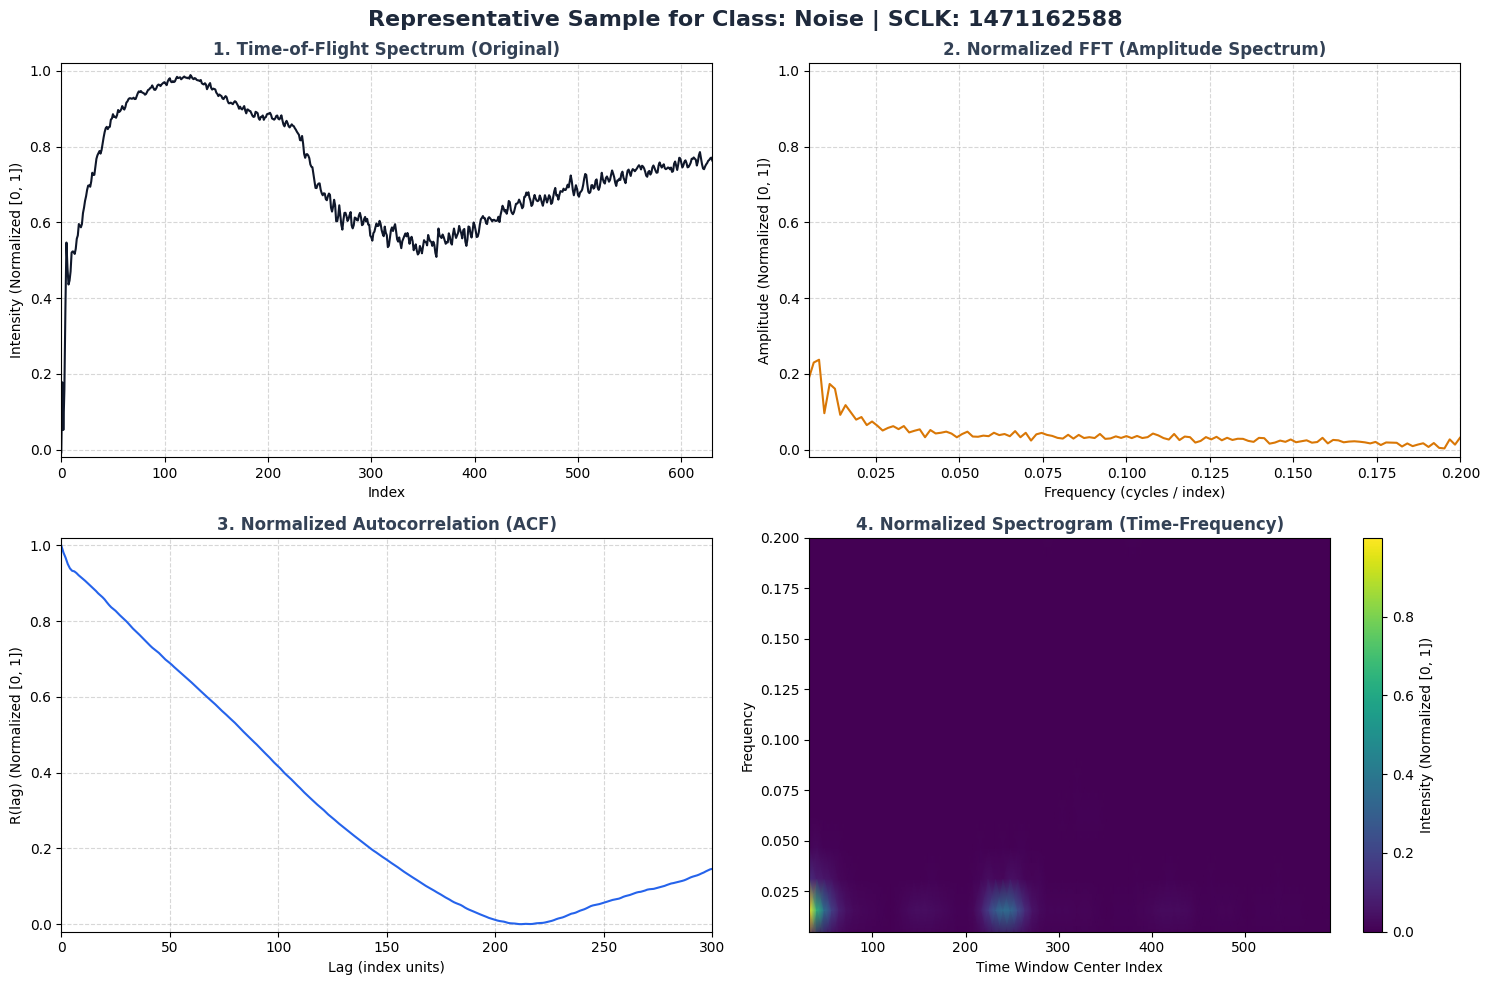

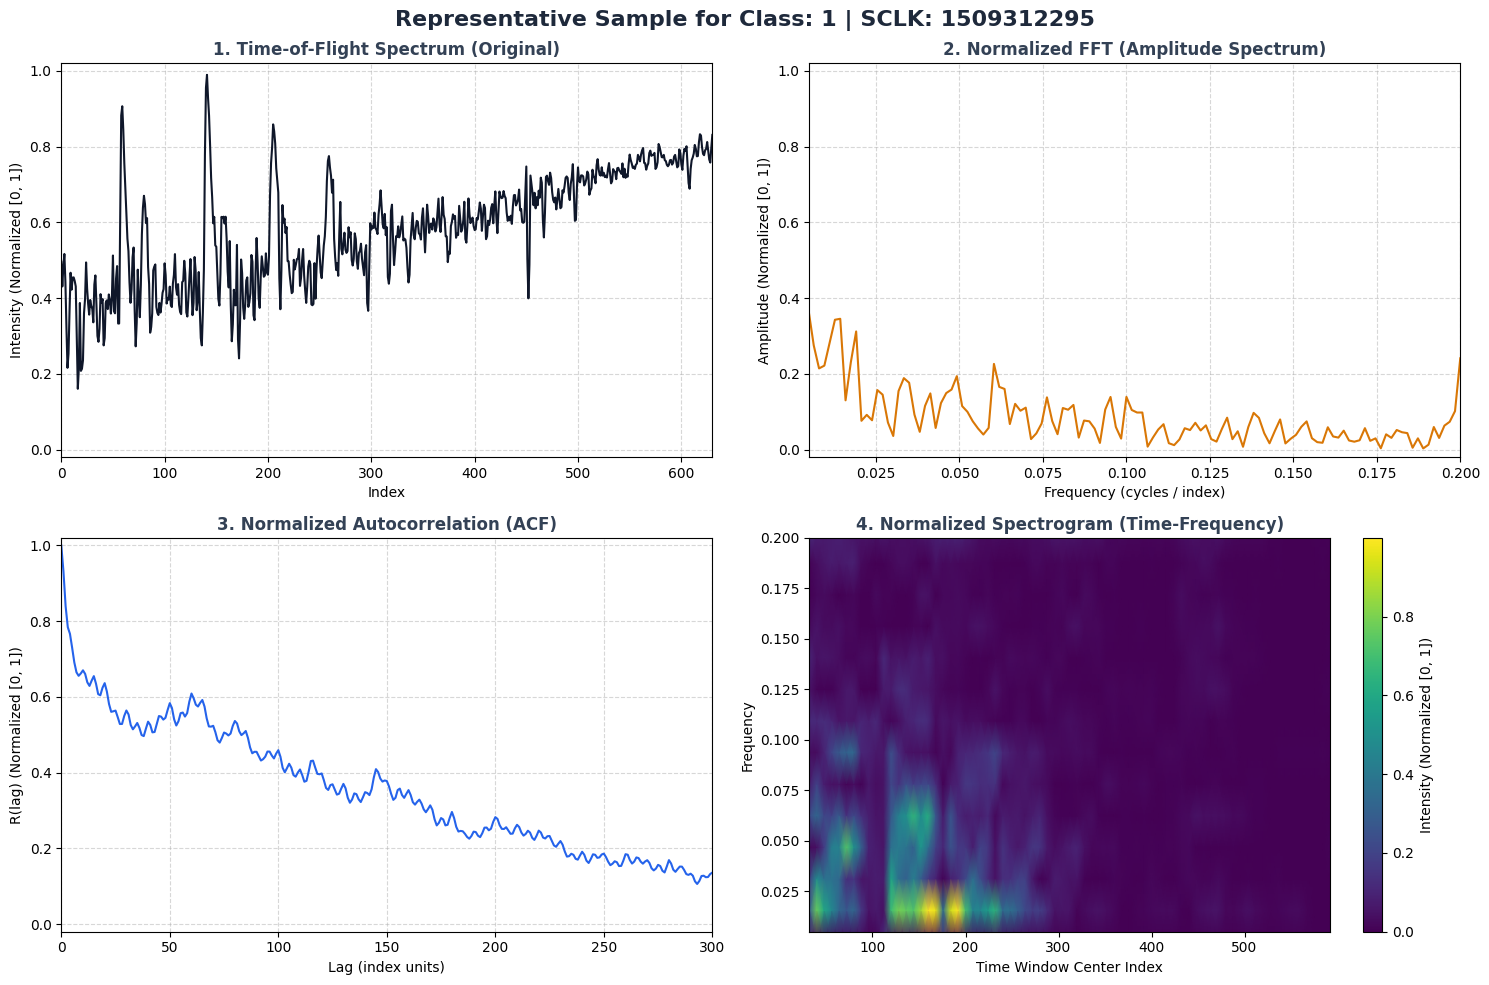

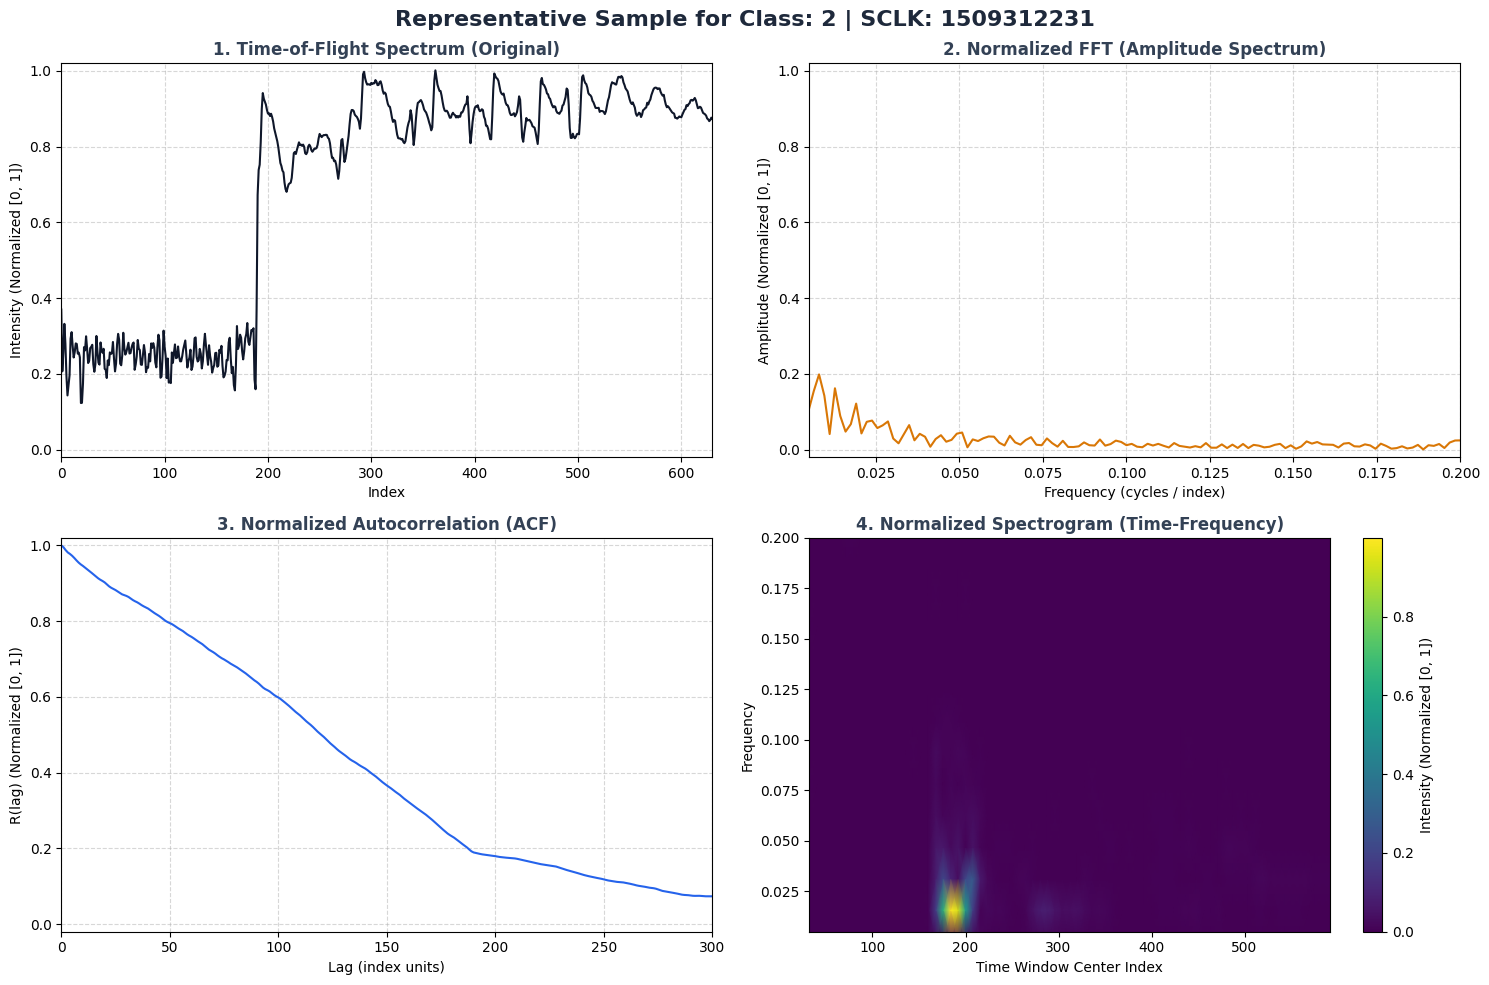

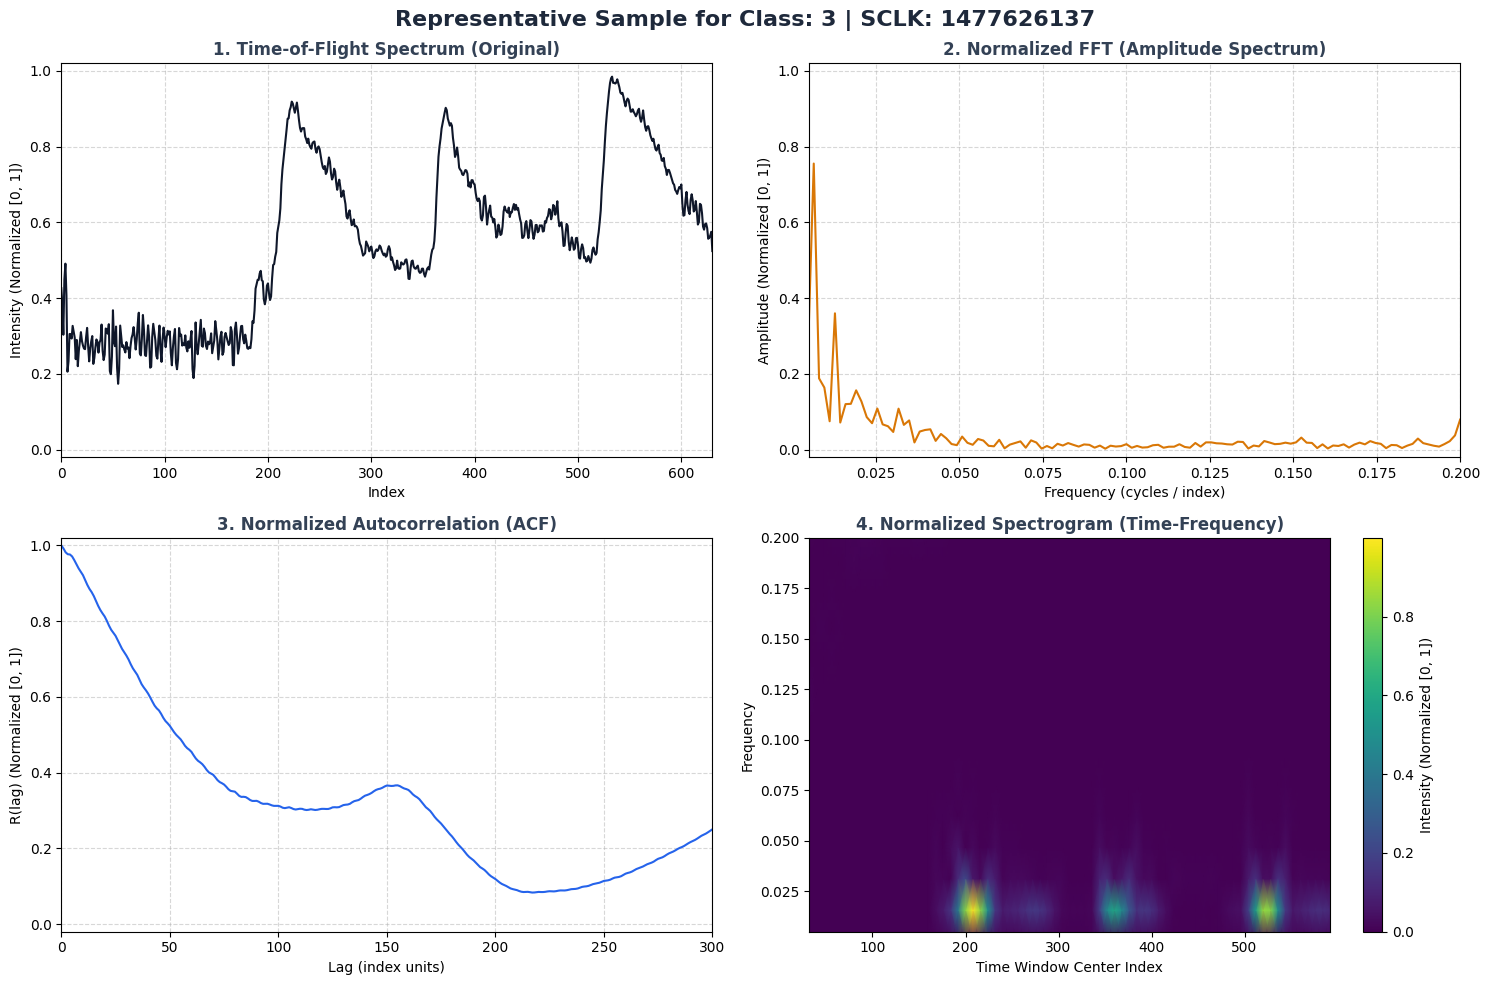

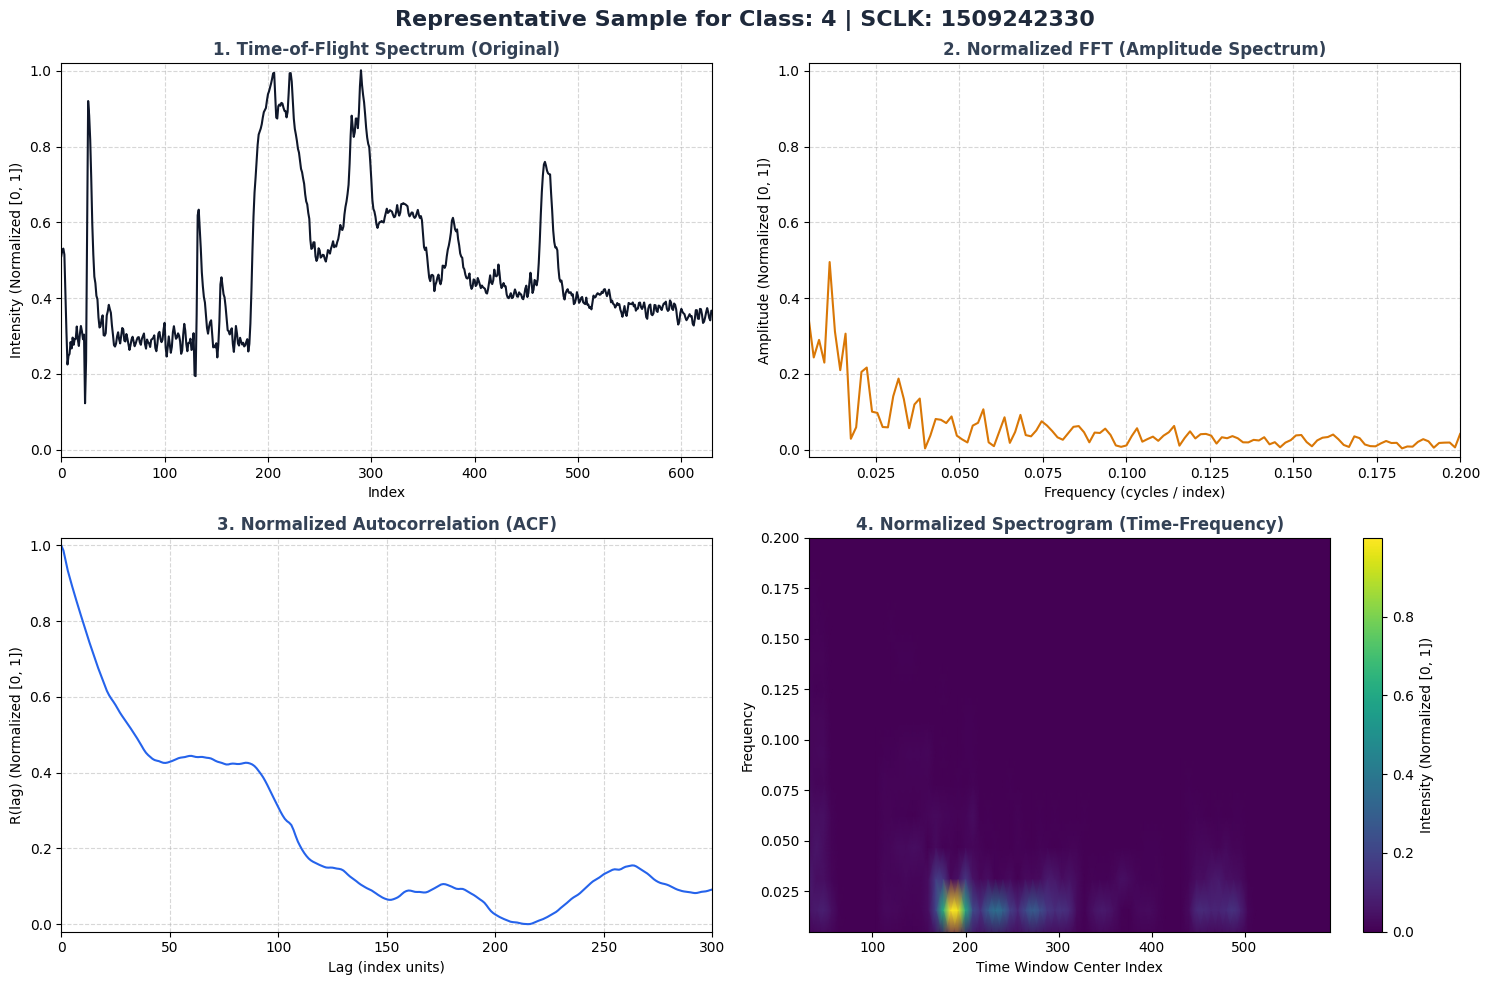

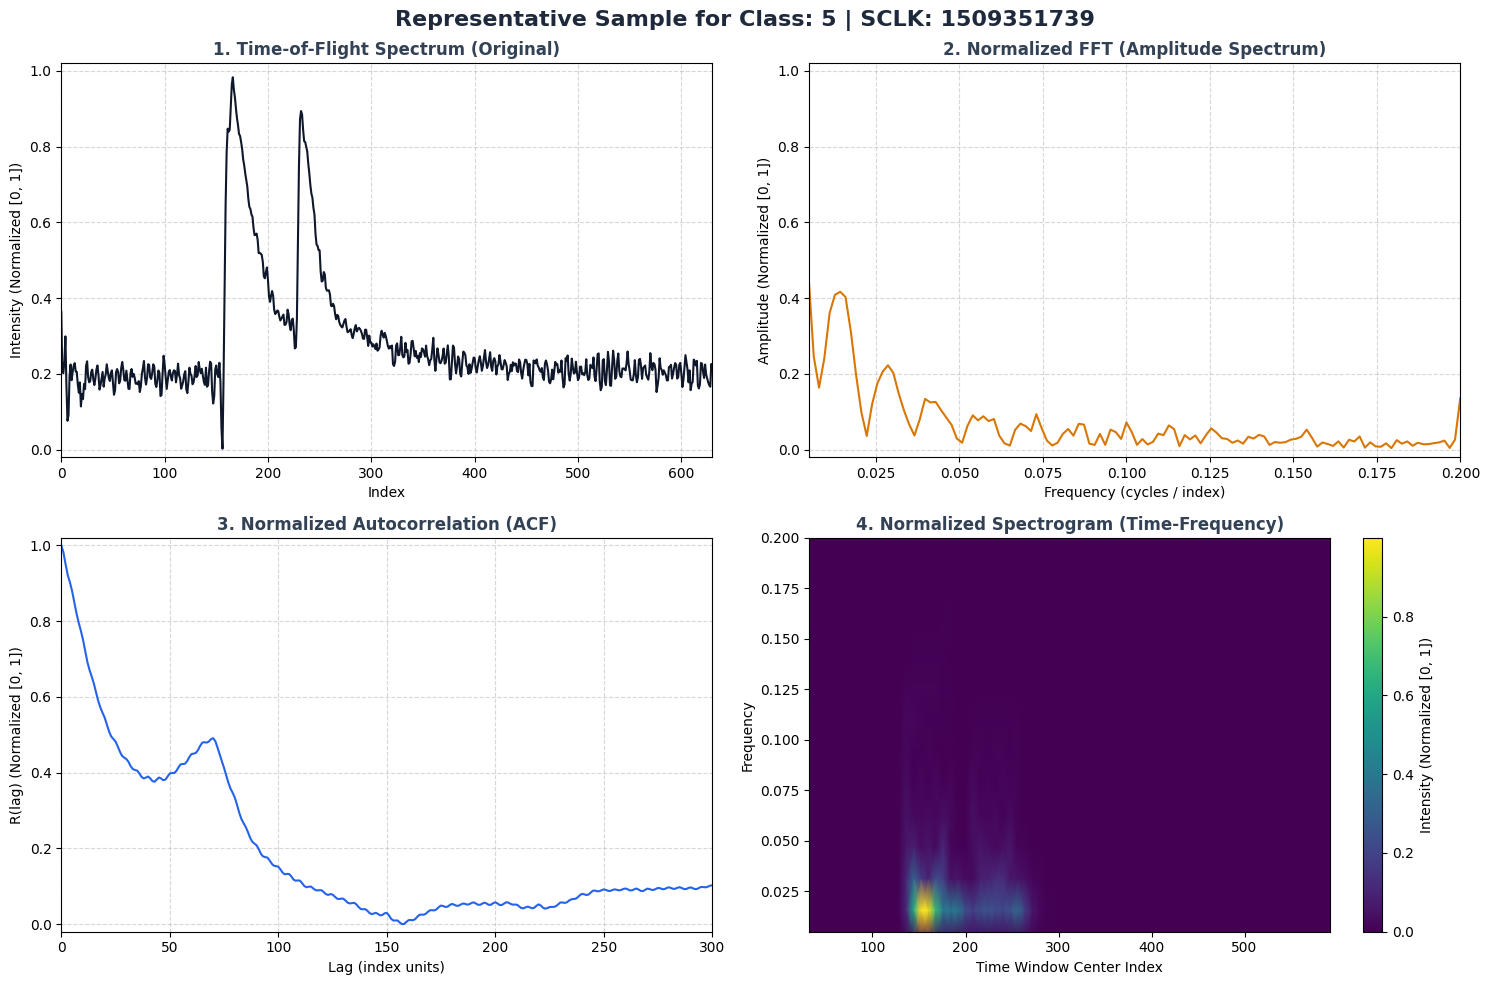

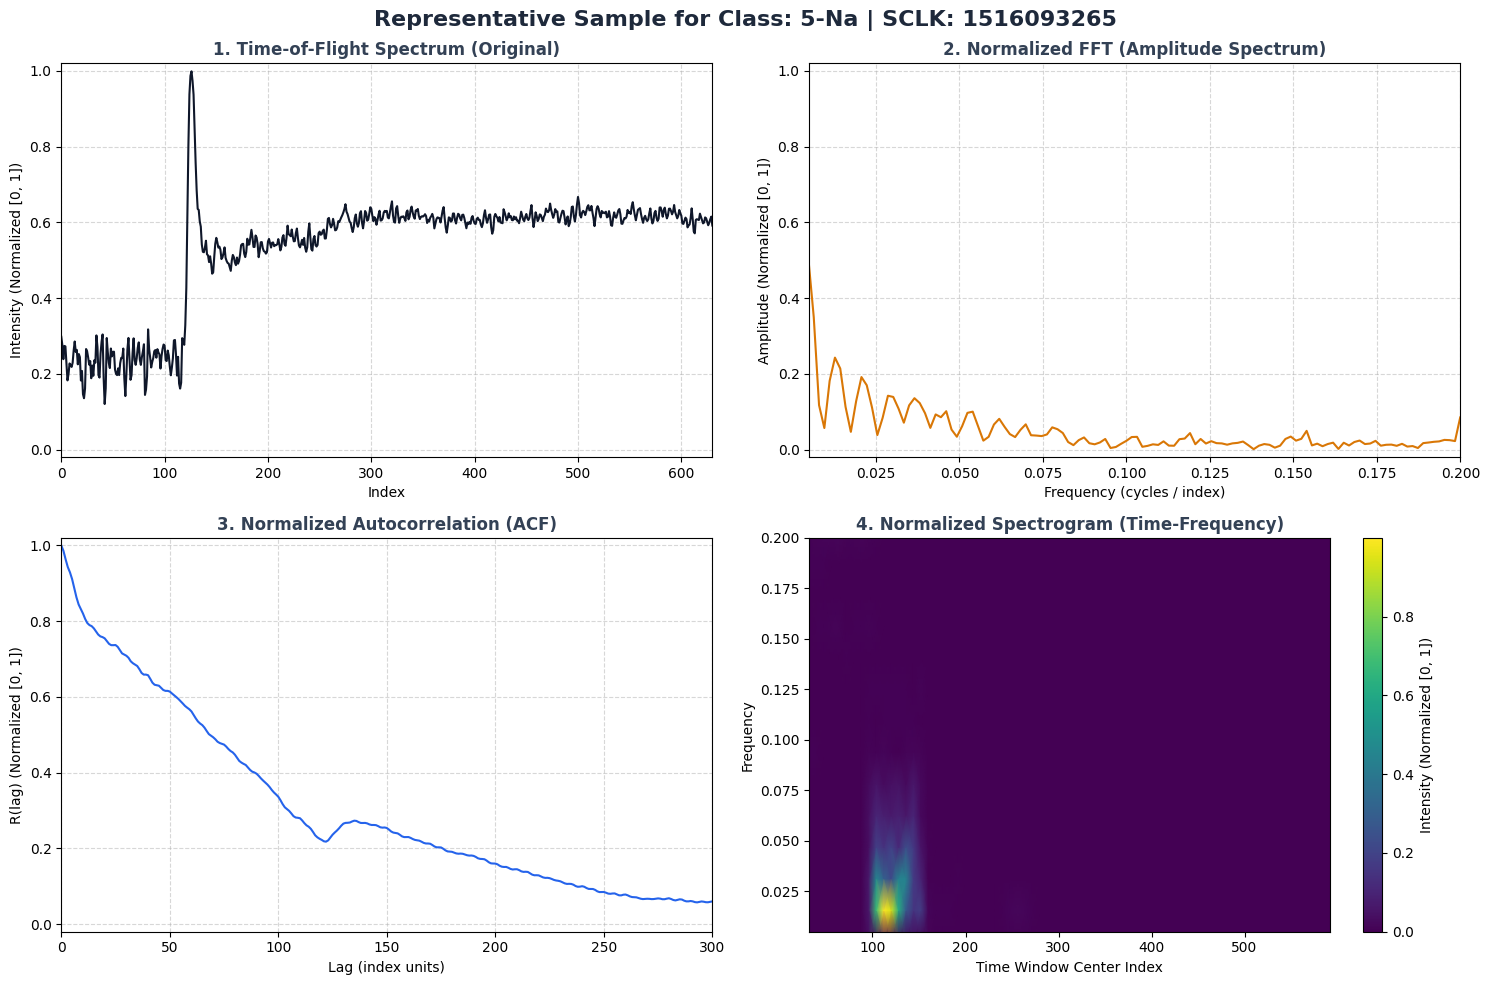

In [8]:
classes = ['Noise', '1', '2', '3', '4', '5', '5-Na']

for cls in classes:
    cls_subset = full_df[full_df['class'] == cls]
    if len(cls_subset) > 0:
        # Sample the first instance
        sample = cls_subset.iloc[1]
        plot_class_diagnostics(sample, title_prefix=f"Representative Sample for ")
    else:
        print(f"Warning: No samples found for class '{cls}'")

## Analysis and Findings

Based on the generated plots, we can confirm several key visual and mathematical insights:

### 1. Class 1 (Constant Spacing)
- **Spectrum**: Showcases clear, distinct peak intervals starting early and decaying to the right.
- **FFT**: Features a highly pronounced, sharp harmonic peak near frequency `~0.015 - 0.02` (corresponding to spacing $1 / 60 \approx 0.016$). This single peak is an unmistakable finger-print.
- **Autocorrelation**: Displays very strong, periodic, and cleanly repeating wave-like peaks at lags of 60, 120, 180, etc.
- **Spectrogram**: Displays a clear, horizontal band of elevated intensity, representing a constant frequency over time.

### 2. Class 2 (Decreasing Spacing)
- **FFT**: Has a broader, less sharp frequency profile because the spacing converges.
- **Autocorrelation**: Features a rapidly decaying curve that loses peak definition at larger lags.
- **Spectrogram**: The dominant frequency band displays a slight **upward slope** from left to right as the peaks converge.

### 3. Class 4 (Increasing Spacing)
- **FFT**: Broadened and shifted towards the lower frequencies at higher index values.
- **Autocorrelation**: Rapidly dampens and exhibits no clear periodic peaks.
- **Spectrogram**: The frequency signature shows a distinct **downward slope** as the peaks diverge.

### 4. Noise Class
- **Spectrum**: Chaotic, narrow electronic trigger spike followed by broad digitizer grass.
- **FFT**: Entirely flat, low-level white-noise background with no dominant peak.
- **Autocorrelation**: Plummets to zero almost instantly after lag 0, confirming the lack of correlation between successive samples.
- **Spectrogram**: Displays a uniform, diffuse green/blue noise floor without any structured bands.